# Makine Öğrenmesi Tabanlı Ağ Saldırı Tespit Sistemi

# Veri Setinin İncelenmesi

## Genel Akış


Notebook genel akışı şu şekildedir:

1. Veri setinin yüklenmesi ve tanıtılması  
2. Eksik, sonsuz ve tekrar eden değerlerin kontrol edilmesi  
3. Keşifsel veri analizi yapılması  
4. Modelleme için veri hazırlığı  
5. Logistic Regression, Decision Tree, Random Forest ve XGBoost modellerinin eğitilmesi  
6. Modellerin performans karşılaştırması  
7. Feature importance analizi  
8. Confusion matrix ile hata analizi  
9. Risk seviyesi ve güvenlik aksiyonlarının çıkarılması  
10. Genel sonuçların değerlendirilmesi  

## 1. Veri Seti

In [1]:
import pandas as pd

df = pd.read_parquet("../dataset/Benign-Monday-no-metadata.parquet")

df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


## 1.0 Veri Seti Bilgileri

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 458831 entries, 0 to 458830
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  458831 non-null  int8    
 1   Flow Duration             458831 non-null  int32   
 2   Total Fwd Packets         458831 non-null  int32   
 3   Total Backward Packets    458831 non-null  int32   
 4   Fwd Packets Length Total  458831 non-null  int32   
 5   Bwd Packets Length Total  458831 non-null  int32   
 6   Fwd Packet Length Max     458831 non-null  int16   
 7   Fwd Packet Length Min     458831 non-null  int16   
 8   Fwd Packet Length Mean    458831 non-null  float32 
 9   Fwd Packet Length Std     458831 non-null  float32 
 10  Bwd Packet Length Max     458831 non-null  int16   
 11  Bwd Packet Length Min     458831 non-null  int16   
 12  Bwd Packet Length Mean    458831 non-null  float32 
 13  Bwd Packet Length Std     458831 non-nul

## 1.1 Veri Setinin Genel Yapısı

In [3]:

print(df.shape)


print(df.columns)

(458831, 78)
Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Cou

### 1.2 Hedef Değişken Dağılımı

In [4]:

df["Label"].value_counts()

Label
Benign    458831
Name: count, dtype: int64

In [5]:

df.isnull().sum().sum()

np.int64(0)

### 1.3 Tüm Veri Dosyalarının Birleştirilmesi


In [6]:
import pandas as pd
from pathlib import Path

dataset_path = Path("../dataset")

files = list(dataset_path.glob("*.parquet"))

dfs = []

for file in files:
    print(file.name)
    dfs.append(pd.read_parquet(file))

df = pd.concat(dfs, ignore_index=True)

DDoS-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


### 1.4 Birleştirilmiş Veri Setinin Genel Kontrolü


In [7]:
df.shape

(2313810, 78)

In [8]:
df["Label"].value_counts()

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

## 2. Veri Setinin İncelenmesi ve Ön Kontroller

## 2.0 Eksik Değer Kontrolü

In [9]:
df.isnull().sum().sort_values(ascending=False)

Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
                       ..
Bwd IAT Total           0
Fwd IAT Min             0
Fwd IAT Max             0
Fwd IAT Std             0
Label                   0
Length: 78, dtype: int64

### 2.1 Sayısal Özelliklerin İstatistiksel Özeti



In [10]:
df.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,...,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2313810.0,2313810.00,2.313810e+06,2.313810e+06
mean,1.050673e+01,1.807575e+07,1.108391e+01,1.255334e+01,6.664045e+02,1.976976e+04,2.506291e+02,2.142396e+01,6.880503e+01,8.299154e+01,...,6.537630e+00,-3.360480e+03,9.977087e+04,5.032397e+04,1.874053e+05,7.131980e+04,10172610.0,616408.75,1.063716e+07,9.688133e+06
std,5.416040e+00,3.640823e+07,8.291879e+02,1.103179e+03,1.105009e+04,2.503141e+06,7.855073e+02,6.334192e+01,2.023045e+02,3.078814e+02,...,7.039324e+02,1.200084e+06,7.161351e+05,4.345795e+05,1.131814e+06,6.375820e+05,25771430.0,5084448.50,2.656441e+07,2.550670e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
25%,6.000000e+00,4.760000e+02,2.000000e+00,1.000000e+00,3.700000e+01,2.600000e+01,2.000000e+01,0.000000e+00,8.666667e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
50%,6.000000e+00,6.478300e+04,2.000000e+00,2.000000e+00,7.400000e+01,1.830000e+02,4.300000e+01,6.000000e+00,3.955556e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
75%,1.700000e+01,5.856948e+06,6.000000e+00,5.000000e+00,3.560000e+02,2.306000e+03,2.740000e+02,3.900000e+01,5.400000e+01,8.499406e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00,0.000000e+00,0.000000e+00
max,1.700000e+01,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,120000000.0,76900000.00,1.200000e+08,1.200000e+08


## 2.2 Veri Tiplerinin İncelenmesi

In [11]:
df.dtypes


Protocol                       int8
Flow Duration                 int32
Total Fwd Packets             int32
Total Backward Packets        int32
Fwd Packets Length Total      int32
                             ...   
Idle Mean                   float32
Idle Std                    float32
Idle Max                      int32
Idle Min                      int32
Label                           str
Length: 78, dtype: object

### 2.3 Sınıf İsimlerinin ve Sayısının İncelenmesi

In [12]:
df["Label"].unique()

<ArrowStringArray>
[                    'Benign',                       'DDoS',
                'FTP-Patator',                'SSH-Patator',
                        'Bot',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed',
               'Infiltration',                   'PortScan',
   'Web Attack � Brute Force',           'Web Attack � XSS',
 'Web Attack � Sql Injection']
Length: 15, dtype: str

In [13]:
len(df["Label"].unique())

15

### 2.4 Sınıf Dağılımının Görselleştirilmesi




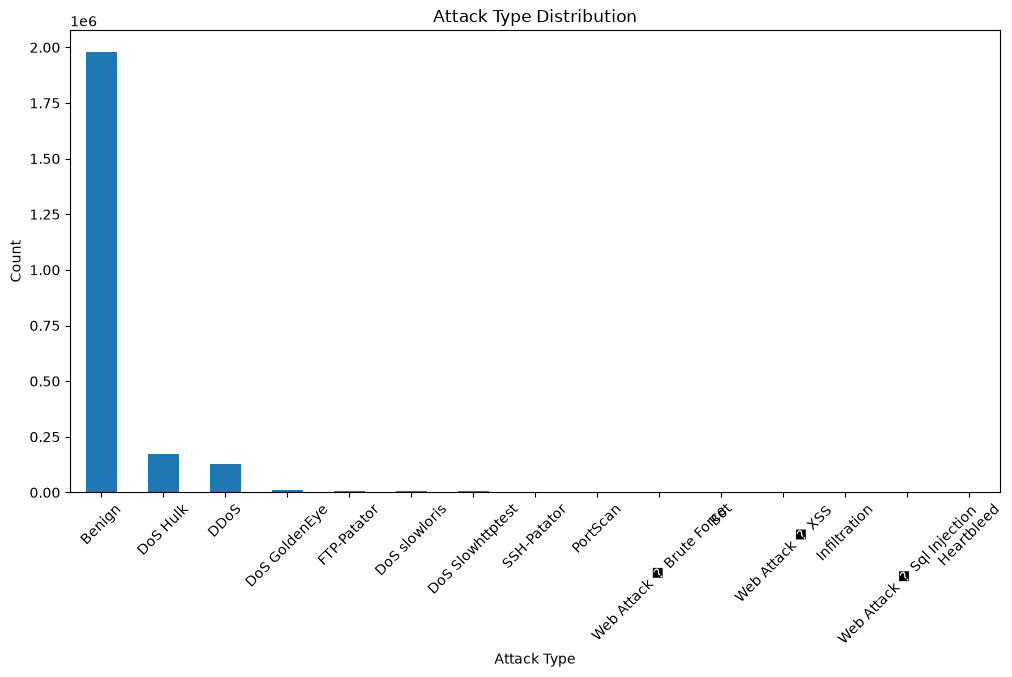

In [14]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar", figsize=(12,6))
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 3. Veri Ön İşleme


### 3.0 Eksik Değer Kontrolü

Bu adımda veri setindeki eksik değerler sütun bazında kontrol edilmiştir.

In [15]:
df.isnull().sum().sort_values(ascending=False)

Protocol                0
CWE Flag Count          0
Fwd Avg Packets/Bulk    0
Fwd Avg Bytes/Bulk      0
Avg Bwd Segment Size    0
                       ..
Bwd IAT Total           0
Fwd IAT Min             0
Fwd IAT Max             0
Fwd IAT Std             0
Label                   0
Length: 78, dtype: int64

### 3.1 Sonsuz Değer Kontrolü

In [16]:
import numpy as np

np.isinf(df.select_dtypes(include=np.number)).sum()

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Active Min                  0
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Length: 77, dtype: int64

### 3.2 Tekrar Eden Değer Kontrolü

In [17]:
df.duplicated().sum()

np.int64(82004)

## 4. Veri Analizi / Keşifsel Veri Analizi

### 4.0 Sayısal Özelliklerin İstatistiksel Özeti



In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Protocol,2313810.0,1.050673e+01,5.416040e+00,0.0,6.0,6.0,17.00,17.0
Flow Duration,2313810.0,1.807575e+07,3.640823e+07,-13.0,476.0,64783.0,5856947.75,119999998.0
Total Fwd Packets,2313810.0,1.108391e+01,8.291879e+02,1.0,2.0,2.0,6.00,219759.0
Total Backward Packets,2313810.0,1.255334e+01,1.103179e+03,0.0,1.0,2.0,5.00,291922.0
Fwd Packets Length Total,2313810.0,6.664045e+02,1.105009e+04,0.0,37.0,74.0,356.00,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2313810.0,7.131980e+04,6.375820e+05,0.0,0.0,0.0,0.00,110000000.0
Idle Mean,2313810.0,1.017261e+07,2.577143e+07,0.0,0.0,0.0,0.00,120000000.0
Idle Std,2313810.0,6.164088e+05,5.084448e+06,0.0,0.0,0.0,0.00,76900000.0
Idle Max,2313810.0,1.063716e+07,2.656441e+07,0.0,0.0,0.0,0.00,120000000.0


### 4.1 Seçili Özellikler Arası Korelasyon


In [19]:
cols = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

df[cols].corr()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s
Flow Duration,1.000000,0.020296,0.019142,-0.030496,-0.081625
Total Fwd Packets,0.020296,1.000000,0.999070,0.002611,-0.001596
Total Backward Packets,0.019142,0.999070,1.000000,0.002449,-0.001622
Flow Bytes/s,-0.030496,0.002611,0.002449,1.000000,0.258596
Flow Packets/s,-0.081625,-0.001596,-0.001622,0.258596,1.000000


## 5. Feature Engineering


### 5.0 Hedef Değişkenin Sayısallaştırılması

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Label"] = le.fit_transform(df["Label"])

### 5.1 Kodlanmış Hedef Değişkenin Kontrolü

In [21]:
df["Label"].head()

0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64

### 5.2 Bağımsız Değişkenler ve Hedef Değişkenin Ayrılması

In [22]:
X = df.drop("Label", axis=1)
y = df["Label"]

print(X.shape)
print(y.shape)

(2313810, 77)
(2313810,)


### 5.3 Eğitim ve Test Verisinin Ayrılması


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1851048, 77)
(462762, 77)


## 6. Model 1 - Random Forest

### 6.0 Random Forest Modelinin Tanımlanması ve Eğitilmesi

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### 6.1 Random Forest Tahminlerinin Alınması


In [25]:
y_pred = model.predict(X_test)

### 6.2 Random Forest Accuracy Sonucu

Bu adımda Random Forest modelinin test verisi üzerindeki doğruluk oranı hesaplanmıştır.

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9985046308901768


### 6.3 Random Forest Sınıflandırma Raporu

Bu raporda Random Forest modelinin precision, recall ve F1-score değerleri sınıf bazında incelenmiştir. Bu metrikler özellikle dengesiz veri setlerinde accuracy değerinden daha detaylı bilgi verir.

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395464
           1       0.84      0.69      0.76       288
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.95      0.99      0.97      1046
           6       1.00      0.99      0.99      1077
           7       1.00      0.99      1.00      1186
           8       1.00      1.00      1.00         2
           9       1.00      0.71      0.83         7
          10       0.92      0.90      0.91       391
          11       1.00      0.98      0.99       644
          12       0.75      0.77      0.76       294
          13       1.00      0.25      0.40         4
          14       0.43      0.31      0.36       130

    accuracy                           1.00    462762
   macro avg       0.92      0.84      0.86    462762
weighted avg       1.00   

### 6.4 Random Forest Confusion Matrix

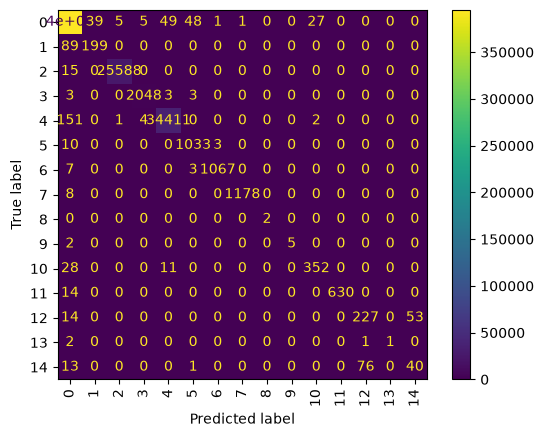

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=90
)

### 6.5 Random Forest Feature Importance


In [29]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
12,Bwd Packet Length Mean,0.058630
13,Bwd Packet Length Std,0.058347
42,Packet Length Variance,0.056220
54,Avg Bwd Segment Size,0.055401
10,Bwd Packet Length Max,0.047367
5,Bwd Packets Length Total,0.044525
41,Packet Length Std,0.039217
22,Fwd IAT Std,0.037279
52,Avg Packet Size,0.032634
64,Subflow Bwd Bytes,0.030943


### 6.6 Random Forest Feature Importance Grafiği

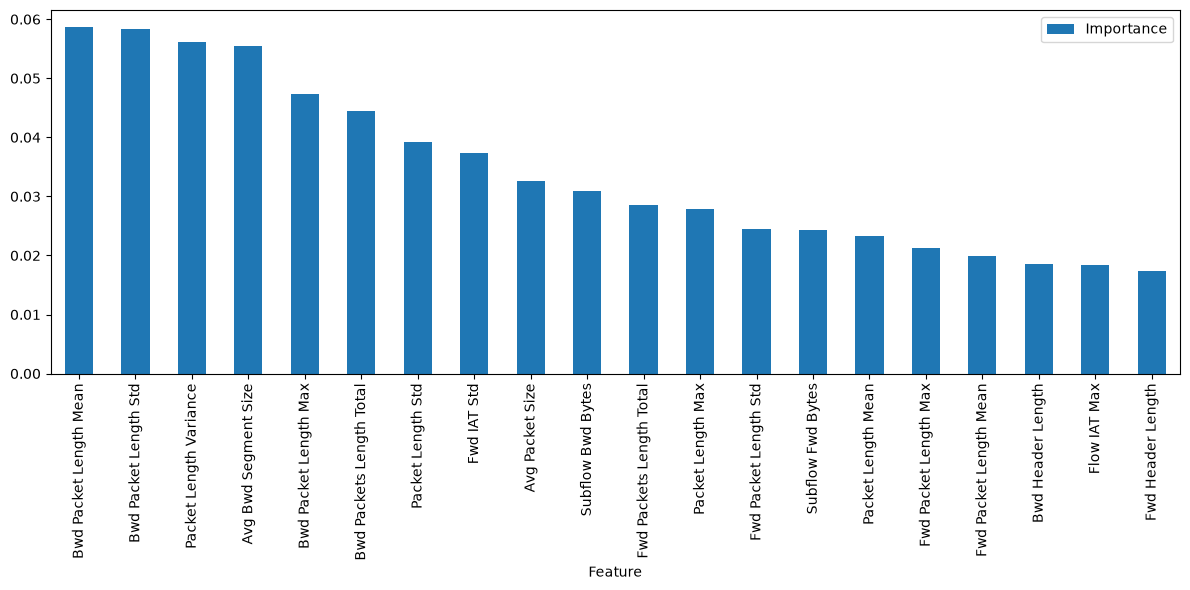

In [30]:
import matplotlib.pyplot as plt

importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

## 7. Model 2 - Decision Tree

### 7.0 Decision Tree Modelinin Eğitilmesi

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 7.1 Decision Tree Tahminlerinin Alınması

Bu adımda eğitilen Decision Tree modeli test verisi üzerinde tahmin yapmıştır.

In [32]:
y_pred_dt = dt.predict(X_test)

### 7.2 Decision Tree Accuracy Sonucu


In [33]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9985608152786962


### 7.3 Decision Tree Sınıflandırma Raporu



In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395464
           1       0.72      0.74      0.73       288
           2       1.00      1.00      1.00     25603
           3       0.99      1.00      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.96      0.96      0.96      1046
           6       0.99      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      1.00      1.00         2
           9       0.62      0.71      0.67         7
          10       0.90      0.90      0.90       391
          11       1.00      1.00      1.00       644
          12       0.74      0.74      0.74       294
          13       0.40      0.50      0.44         4
          14       0.42      0.42      0.42       130

    accuracy                           1.00    462762
   macro avg       0.85      0.86      0.86    462762
weighted avg       1.00   

### 7.4 Decision Tree Confusion Matrix

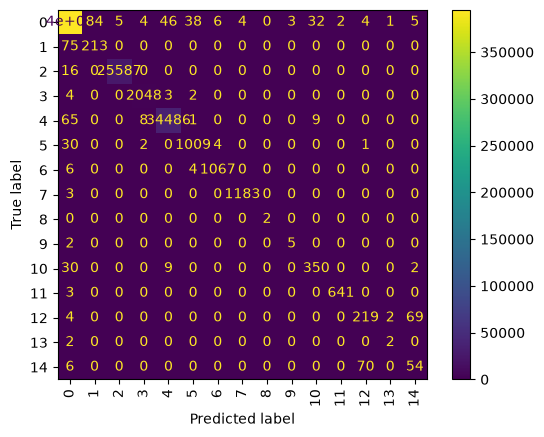

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.show()

### 7.5 Decision Tree Feature Importance

In [36]:
import pandas as pd

importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance_dt = importance_dt.sort_values(
    by="Importance",
    ascending=False
)

importance_dt.head(20)

,Feature,Importance
13,Bwd Packet Length Std,0.502006
6,Fwd Packet Length Max,0.170178
67,Fwd Act Data Packets,0.094092
37,Bwd Packets/s,0.037135
4,Fwd Packets Length Total,0.019589
34,Fwd Header Length,0.019138
65,Init Fwd Win Bytes,0.018295
5,Bwd Packets Length Total,0.017946
64,Subflow Bwd Bytes,0.017535
24,Fwd IAT Min,0.015210


### 7.6 Decision Tree Feature Importance Grafiği

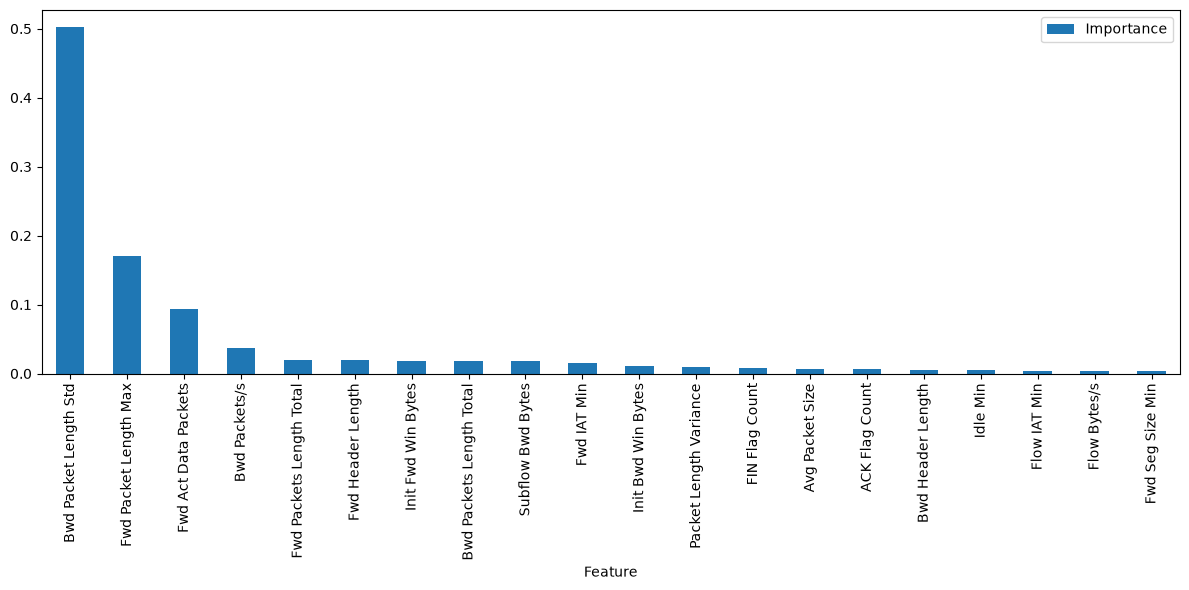

In [37]:
importance_dt.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

## 8. Model 3 - XGBoost

In [38]:
from xgboost import XGBClassifier

### 8.0 XGBoost İçin Hedef Değişkenin Hazırlanması

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

### 8.1 XGBoost Modelinin Tanımlanması

In [40]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    eval_metric="mlogloss"
)

### 8.2 XGBoost İçin Eğitim ve Test Verisinin Ayrılması

In [41]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

### 8.3 XGBoost Modelinin Eğitilmesi

In [42]:
xgb.fit(X_train2, y_train2)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

### 8.4 XGBoost Tahminlerinin Alınması



In [43]:
y_pred_xgb = xgb.predict(X_test2)

### 8.5 XGBoost Accuracy Sonucu

Bu adımda XGBoost modelinin test verisi üzerindeki doğruluk oranı hesaplanmıştır.

In [44]:
from sklearn.metrics import accuracy_score

accuracy_xgb = accuracy_score(y_test2, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.9988028403369335


### 8.6 XGBoost Sınıflandırma Raporu


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test2, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395609
           1       0.86      0.62      0.72       316
           2       1.00      1.00      1.00     25410
           3       1.00      0.99      0.99      2097
           4       1.00      1.00      1.00     34540
           5       0.94      0.99      0.96      1084
           6       1.00      0.99      0.99      1099
           7       1.00      1.00      1.00      1179
           8       1.00      1.00      1.00         1
           9       1.00      0.57      0.73         7
          10       0.95      0.94      0.94       374
          11       1.00      1.00      1.00       631
          12       0.71      0.95      0.81       288
          13       1.00      0.67      0.80         3
          14       0.45      0.10      0.17       124

    accuracy                           1.00    462762
   macro avg       0.93      0.85      0.87    462762
weighted avg       1.00   

### 8.7 XGBoost Confusion Matrix


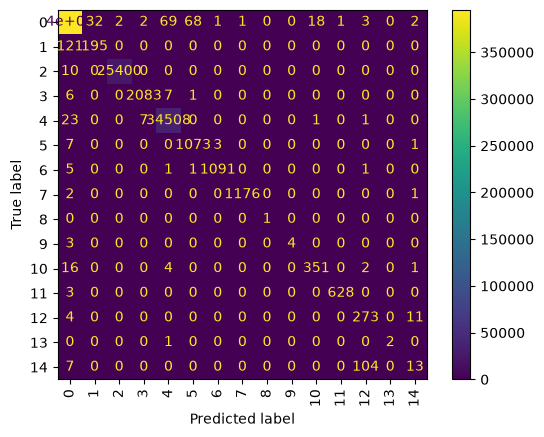

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test2,
    y_test2,
    xticks_rotation=90
)

plt.show()

### 8.8 XGBoost Feature Importance

In [47]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,Bwd Packet Length Std,0.175363
22,Fwd IAT Std,0.082425
3,Total Backward Packets,0.068534
69,Active Mean,0.050545
12,Bwd Packet Length Mean,0.048155
73,Idle Mean,0.047952
67,Fwd Act Data Packets,0.046043
70,Active Std,0.041823
39,Packet Length Max,0.040340
6,Fwd Packet Length Max,0.038957


### 8.9 XGBoost Feature Importance Grafiği


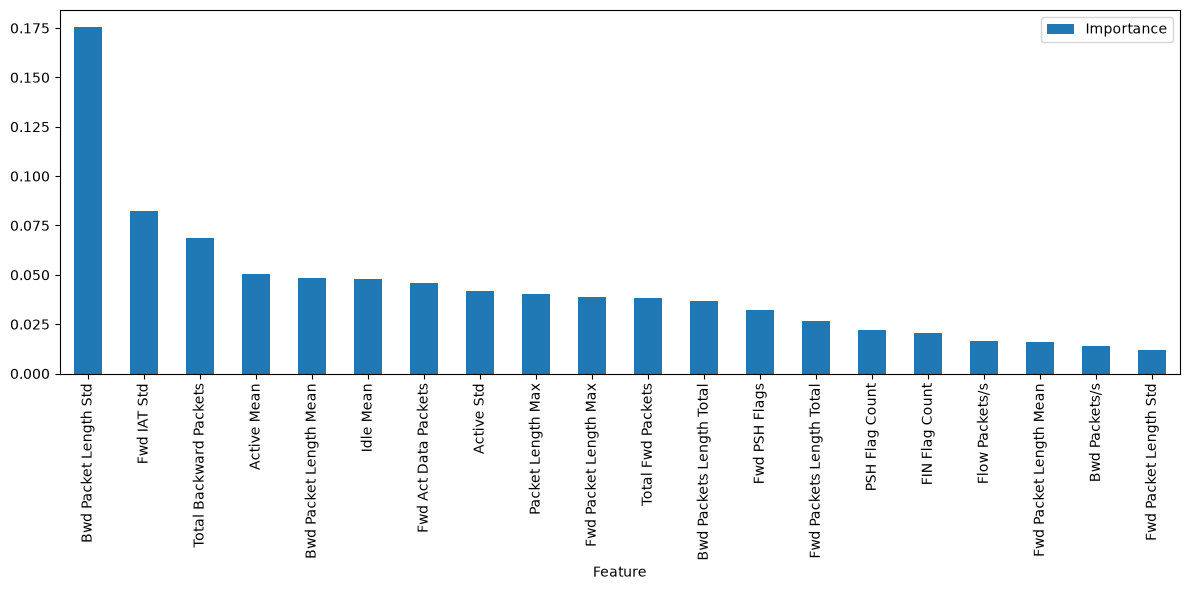

In [48]:
importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

## 9. Risk Analizi

### 9.0 Model Tahmin Güveninin Hesaplanması

In [49]:
import numpy as np

prob = xgb.predict_proba(X_test2)

risk_score = np.max(prob, axis=1)

print(risk_score[:20])

[0.99996746 0.9999628  0.99996305 0.99999166 0.9999436  0.9999442
 0.9999918  0.99999166 0.999949   0.99999154 0.9999578  0.99993217
 0.9997286  0.99967563 0.99999166 0.9999918  0.999703   0.99998546
 0.9873186  0.99999213]


### 9.1 Tahmin Güvenine Göre Seviye Belirleme

In [50]:
risk_level = []

for s in risk_score:

    if s >= 0.95:
        risk_level.append("Yüksek Risk")

    elif s >= 0.80:
        risk_level.append("Orta Risk")

    else:
        risk_level.append("Düşük Risk")

### 9.2 Risk Analizi Sonuç Tablosu


In [51]:
import pandas as pd

result = pd.DataFrame({

    "Gerçek": y_test2,
    "Tahmin": y_pred_xgb,
    "Risk Skoru": risk_score,
    "Risk Seviyesi": risk_level

})

result.head(20)

,Gerçek,Tahmin,Risk Skoru,Risk Seviyesi
0,0,0,0.999967,Yüksek Risk
1,0,0,0.999963,Yüksek Risk
2,3,3,0.999963,Yüksek Risk
3,0,0,0.999992,Yüksek Risk
4,2,2,0.999944,Yüksek Risk
5,2,2,0.999944,Yüksek Risk
6,0,0,0.999992,Yüksek Risk
7,0,0,0.999992,Yüksek Risk
8,0,0,0.999949,Yüksek Risk
9,0,0,0.999992,Yüksek Risk


### 9.3 Sınıf Etiketlerinin Kontrolü

In [52]:
print(le.classes_)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


### 9.4 Veri Setindeki Sayısal Sınıfların Kontrolü

In [53]:
print(df["Label"].unique())

[ 0  2  7 11  1  6  5  4  3  8  9 10 12 14 13]


### 9.5 Sınıf Dağılımının Sayısal Olarak İncelenmesi

In [54]:
df.groupby("Label").size()

Label
0     1977318
1        1437
2      128014
3       10286
4      172846
5        5228
6        5385
7        5931
8          11
9          36
10       1956
11       3219
12       1470
13         21
14        652
dtype: int64

### 9.6 Sayısal Sınıfların Saldırı İsimleriyle Eşleştirilmesi


In [55]:
attack_name = {
    0: "Benign",
    1: "Bot",
    2: "DDoS",
    3: "DoS GoldenEye",
    4: "DoS Hulk",
    5: "DoS Slowhttptest",
    6: "DoS Slowloris",
    7: "FTP-Patator",
    8: "Heartbleed",
    9: "Infiltration",
    10: "PortScan",
    11: "SSH-Patator",
    12: "Web Attack Brute Force",
    13: "Web Attack SQL Injection",
    14: "Web Attack XSS"
}

### 9.7 Saldırı Türlerine Göre Risk Seviyesi Belirleme

In [56]:
risk_map = {
    "Benign":"Düşük Risk",
    "Bot":"Orta Risk",
    "DDoS":"Yüksek Risk",
    "DoS GoldenEye":"Yüksek Risk",
    "DoS Hulk":"Yüksek Risk",
    "DoS Slowhttptest":"Orta Risk",
    "DoS Slowloris":"Yüksek Risk",
    "FTP-Patator":"Orta Risk",
    "Heartbleed":"Kritik Risk",
    "Infiltration":"Kritik Risk",
    "PortScan":"Orta Risk",
    "SSH-Patator":"Orta Risk",
    "Web Attack Brute Force":"Yüksek Risk",
    "Web Attack SQL Injection":"Kritik Risk",
    "Web Attack XSS":"Orta Risk"
}

### 9.8 Model Tahminlerinin Saldırı İsimlerine Dönüştürülmesi

In [57]:
attack_pred = [attack_name[i] for i in y_pred_xgb]

### 9.9 Tahminlere Risk Seviyesi Atanması

In [58]:
risk_level = [risk_map[i] for i in attack_pred]

### 9.10 Nihai Risk Analizi Tablosu

In [59]:
result = pd.DataFrame({
    "Tahmin": attack_pred,
    "Risk Seviyesi": risk_level
})

result.head(20)

,Tahmin,Risk Seviyesi
0,Benign,Düşük Risk
1,Benign,Düşük Risk
2,DoS GoldenEye,Yüksek Risk
3,Benign,Düşük Risk
4,DDoS,Yüksek Risk
5,DDoS,Yüksek Risk
6,Benign,Düşük Risk
7,Benign,Düşük Risk
8,Benign,Düşük Risk
9,Benign,Düşük Risk


### 9.11 Risk Seviyesi Dağılımının Görselleştirilmesi

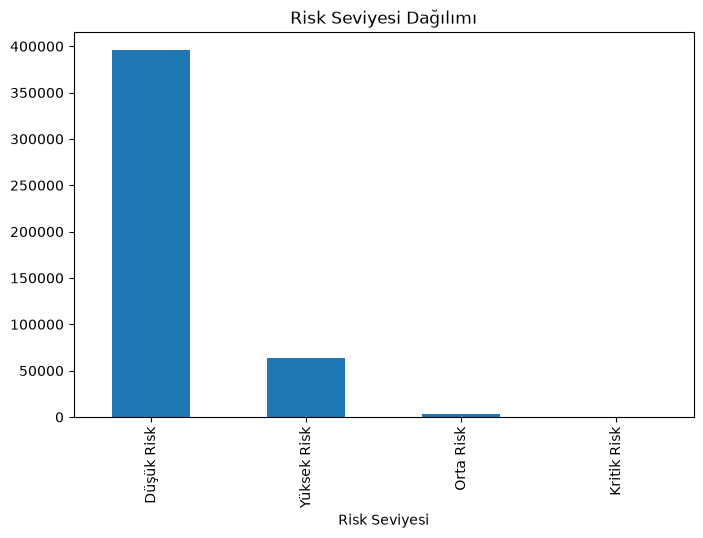

In [60]:
result["Risk Seviyesi"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Seviyesi Dağılımı")
plt.show()

## 10. Güvenlik Aksiyonları

### 10.0 Risk Seviyelerine Göre Aksiyon Eşleştirmesi

In [61]:
action_map = {

"Düşük Risk":"İşlem gerekmiyor",

"Orta Risk":"İzlemeye al",

"Yüksek Risk":"Kaynak IP'yi engelle",

"Kritik Risk":"Sistemi izole et ve güvenlik ekibini uyar"

}

### 10.1 Önerilen Aksiyonların Sonuç Tablosuna Eklenmesi

In [62]:
result["Önerilen Aksiyon"] = result["Risk Seviyesi"].map(action_map)

result.head(20)

,Tahmin,Risk Seviyesi,Önerilen Aksiyon
0,Benign,Düşük Risk,İşlem gerekmiyor
1,Benign,Düşük Risk,İşlem gerekmiyor
2,DoS GoldenEye,Yüksek Risk,Kaynak IP'yi engelle
3,Benign,Düşük Risk,İşlem gerekmiyor
4,DDoS,Yüksek Risk,Kaynak IP'yi engelle
5,DDoS,Yüksek Risk,Kaynak IP'yi engelle
6,Benign,Düşük Risk,İşlem gerekmiyor
7,Benign,Düşük Risk,İşlem gerekmiyor
8,Benign,Düşük Risk,İşlem gerekmiyor
9,Benign,Düşük Risk,İşlem gerekmiyor


### 10.2 Risk Analizi Sonuçlarının Kaydedilmesi

In [63]:
result.to_csv("risk_analizi_sonuclari.csv", index=False)

## 11. Model 4 - Logistic Regression

### 11.0 Logistic Regression İçin Veri Ölçeklendirme


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 11.1 Logistic Regression Modelinin Eğitilmesi

In [65]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

/Users/omerali/Desktop/microsoft machine learning/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


### 11.2 Logistic Regression Accuracy Sonucu

In [66]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9863493545278135


### 11.3 Logistic Regression Sınıflandırma Raporu

In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    395464
           1       0.25      0.02      0.04       288
           2       1.00      0.97      0.98     25603
           3       0.95      0.85      0.90      2057
           4       0.97      0.94      0.96     34569
           5       0.80      0.79      0.79      1046
           6       0.95      0.57      0.71      1077
           7       0.98      0.97      0.97      1186
           8       0.67      1.00      0.80         2
           9       0.50      0.29      0.36         7
          10       0.76      0.18      0.29       391
          11       0.99      0.90      0.94       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.99    462762
   macro avg       0.65      0.56      0.58    462762
weighted avg       0.98   

/Users/omerali/Desktop/microsoft machine learning/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omerali/Desktop/microsoft machine learning/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omerali/Desktop/microsoft machine learning/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

## 12-Feature Importance Analizi

### 12.0 Random Forest Modelinin Tekrar Eğitilmesi


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### 12.1 Feature Importance Değerlerinin Hesaplanması

In [69]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
12,Bwd Packet Length Mean,0.058630
13,Bwd Packet Length Std,0.058347
42,Packet Length Variance,0.056220
54,Avg Bwd Segment Size,0.055401
10,Bwd Packet Length Max,0.047367
5,Bwd Packets Length Total,0.044525
41,Packet Length Std,0.039217
22,Fwd IAT Std,0.037279
52,Avg Packet Size,0.032634
64,Subflow Bwd Bytes,0.030943


### 12.2 En Önemli 20 Özelliğin Görselleştirilmesi

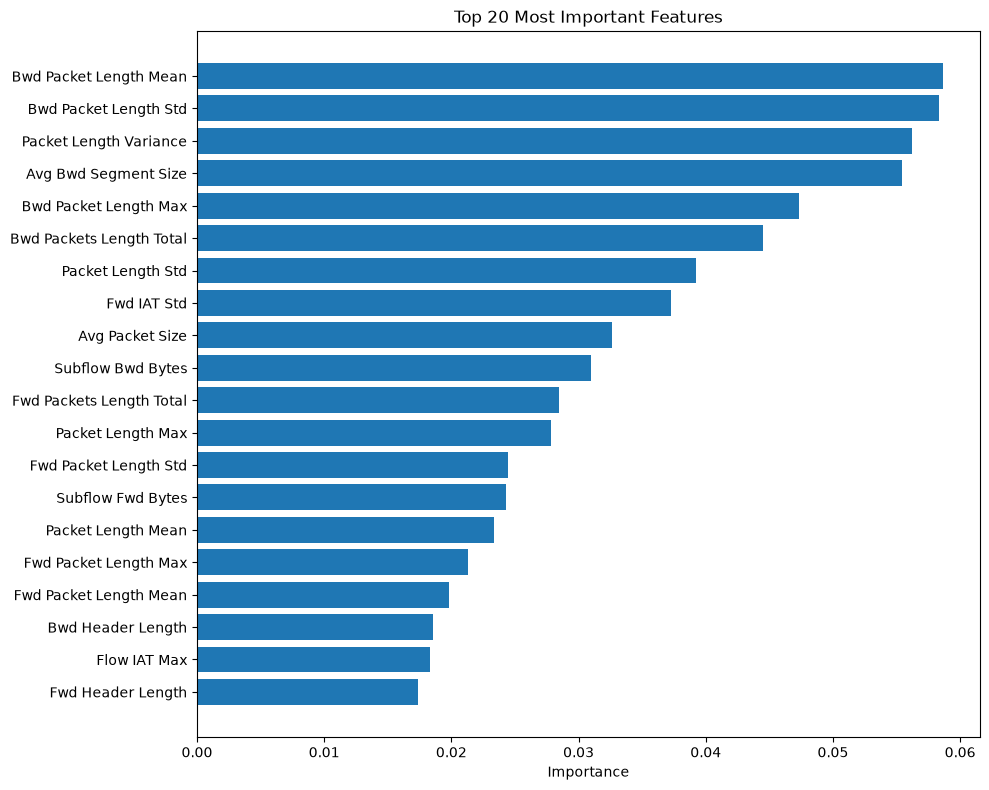

In [70]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 13-Explainable AI (Model Açıklanabilirliği)

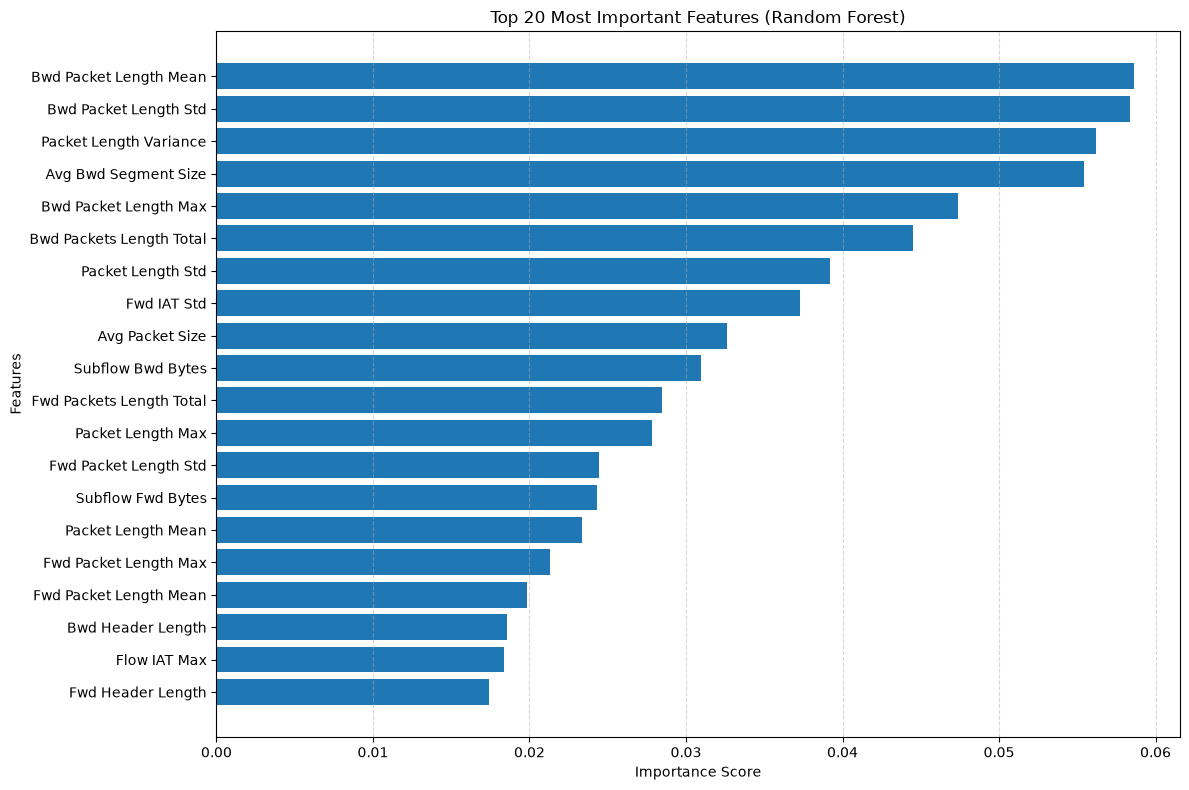

                     Feature  Importance
12    Bwd Packet Length Mean    0.058630
13     Bwd Packet Length Std    0.058347
42    Packet Length Variance    0.056220
54      Avg Bwd Segment Size    0.055401
10     Bwd Packet Length Max    0.047367
5   Bwd Packets Length Total    0.044525
41         Packet Length Std    0.039217
22               Fwd IAT Std    0.037279
52           Avg Packet Size    0.032634
64         Subflow Bwd Bytes    0.030943
4   Fwd Packets Length Total    0.028479
39         Packet Length Max    0.027800
9      Fwd Packet Length Std    0.024440
62         Subflow Fwd Bytes    0.024310
40        Packet Length Mean    0.023328
6      Fwd Packet Length Max    0.021326
8     Fwd Packet Length Mean    0.019835
35         Bwd Header Length    0.018563
18              Flow IAT Max    0.018341
34         Fwd Header Length    0.017394


In [71]:
import matplotlib.pyplot as plt

# Feature importance tablosu
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Büyükten küçüğe sırala
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# İlk 20 özellik
top20 = feature_importance.head(20)

# Grafik
plt.figure(figsize=(12, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()  # En önemli özellik üstte görünsün

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features (Random Forest)")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# İstersen tabloyu da göster
print(top20)

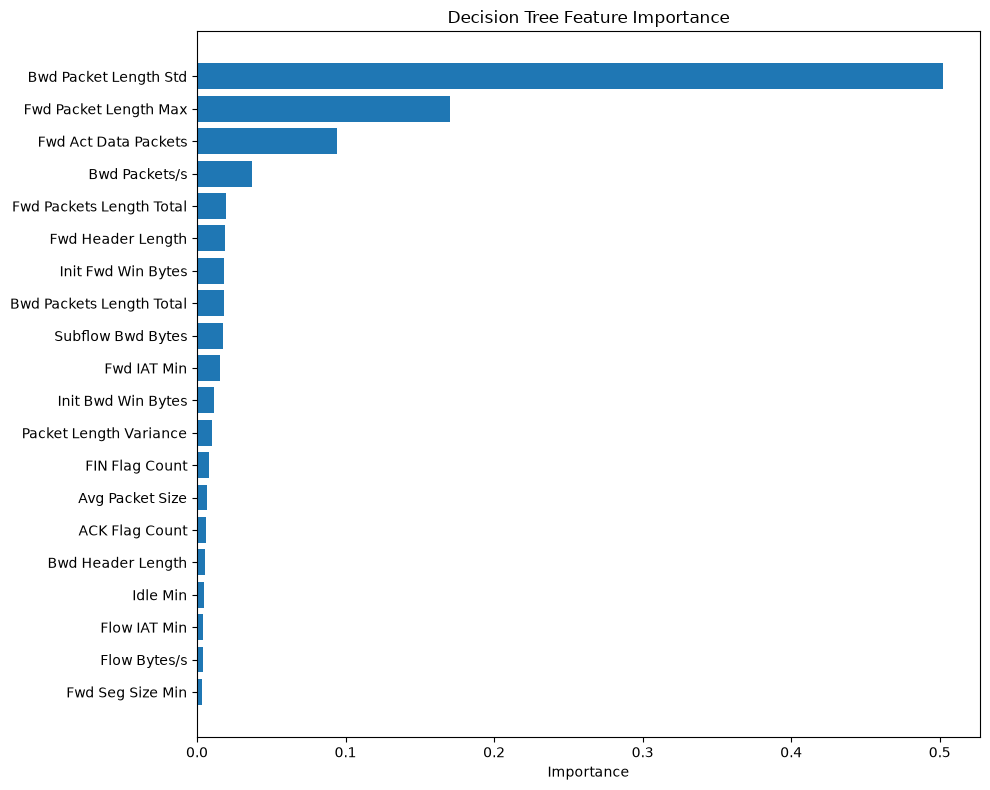

                     Feature  Importance
13     Bwd Packet Length Std    0.502006
6      Fwd Packet Length Max    0.170178
67      Fwd Act Data Packets    0.094092
37             Bwd Packets/s    0.037135
4   Fwd Packets Length Total    0.019589
34         Fwd Header Length    0.019138
65        Init Fwd Win Bytes    0.018295
5   Bwd Packets Length Total    0.017946
64         Subflow Bwd Bytes    0.017535
24               Fwd IAT Min    0.015210
66        Init Bwd Win Bytes    0.011145
42    Packet Length Variance    0.010083
43            FIN Flag Count    0.008233
52           Avg Packet Size    0.006706
47            ACK Flag Count    0.006185
35         Bwd Header Length    0.005523
76                  Idle Min    0.005026
19              Flow IAT Min    0.004129
14              Flow Bytes/s    0.003786
68          Fwd Seg Size Min    0.003466


In [72]:
import matplotlib.pyplot as plt

feature_importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(
    by="Importance",
    ascending=False
)

top20_dt = feature_importance_dt.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20_dt["Feature"][::-1],
    top20_dt["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

print(top20_dt)

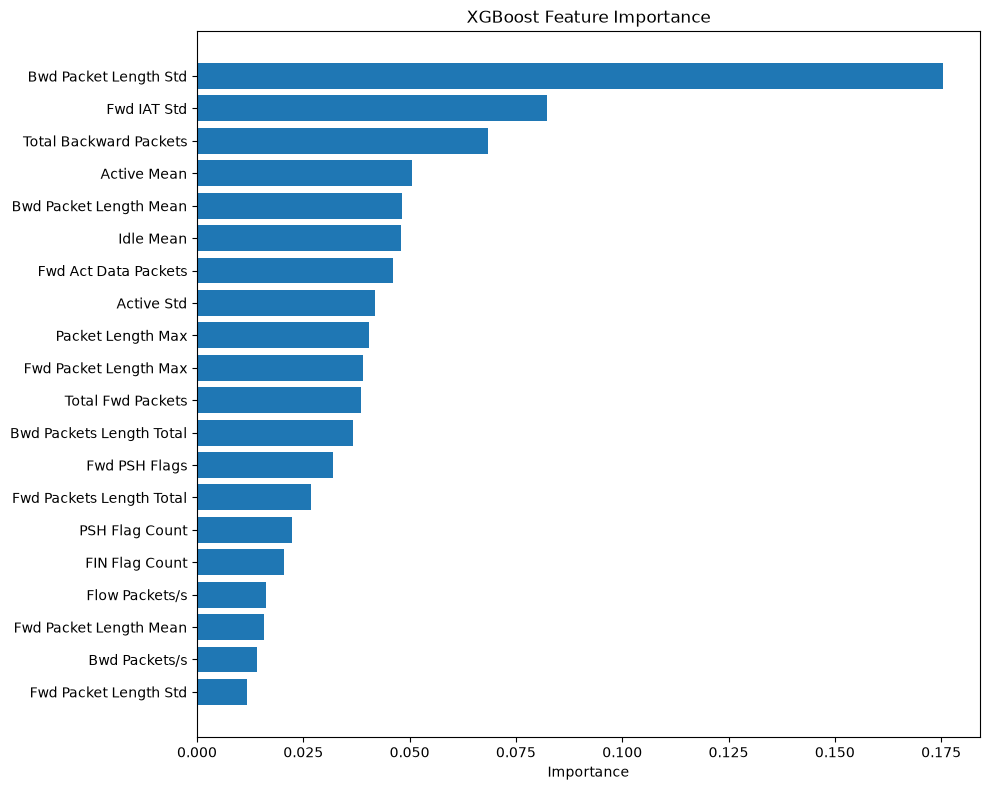

                     Feature  Importance
13     Bwd Packet Length Std    0.175363
22               Fwd IAT Std    0.082425
3     Total Backward Packets    0.068534
69               Active Mean    0.050545
12    Bwd Packet Length Mean    0.048155
73                 Idle Mean    0.047952
67      Fwd Act Data Packets    0.046043
70                Active Std    0.041823
39         Packet Length Max    0.040340
6      Fwd Packet Length Max    0.038957
2          Total Fwd Packets    0.038509
5   Bwd Packets Length Total    0.036674
30             Fwd PSH Flags    0.032003
4   Fwd Packets Length Total    0.026873
46            PSH Flag Count    0.022315
43            FIN Flag Count    0.020528
15            Flow Packets/s    0.016295
8     Fwd Packet Length Mean    0.015802
37             Bwd Packets/s    0.014125
9      Fwd Packet Length Std    0.011831


In [73]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

top20_xgb = feature_importance_xgb.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20_xgb["Feature"][::-1],
    top20_xgb["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print(top20_xgb)

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",3000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [75]:
import sklearn
print(sklearn.__version__)

1.9.0


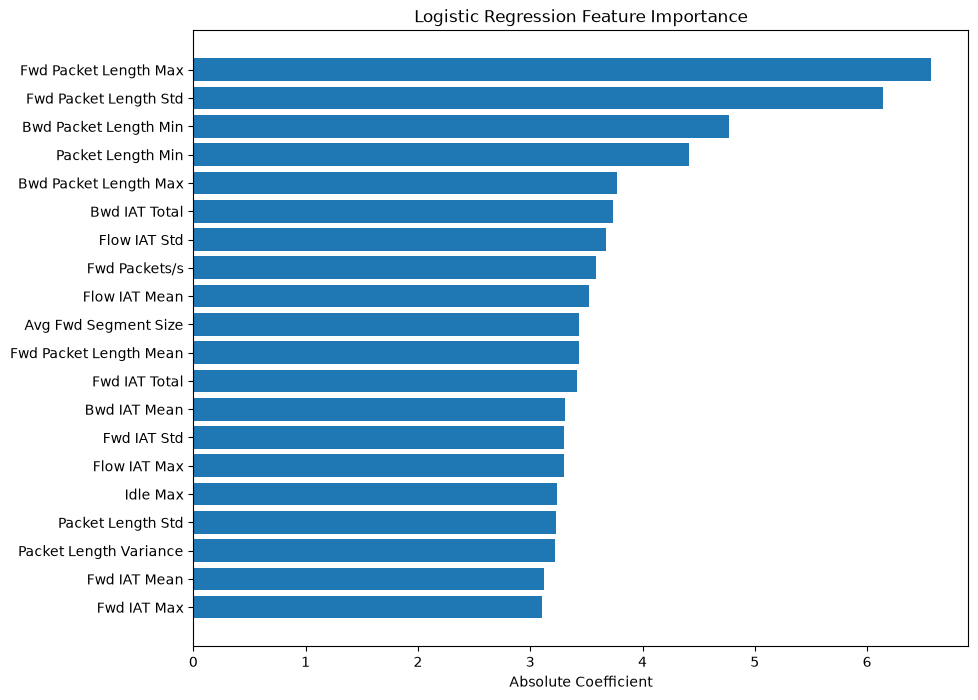

                   Feature  Importance
6    Fwd Packet Length Max    6.573109
9    Fwd Packet Length Std    6.139665
11   Bwd Packet Length Min    4.770327
38       Packet Length Min    4.416183
10   Bwd Packet Length Max    3.772633
25           Bwd IAT Total    3.736377
17            Flow IAT Std    3.673791
36           Fwd Packets/s    3.583501
16           Flow IAT Mean    3.525977
53    Avg Fwd Segment Size    3.436059
8   Fwd Packet Length Mean    3.436059
20           Fwd IAT Total    3.415981
26            Bwd IAT Mean    3.312705
22             Fwd IAT Std    3.301850
18            Flow IAT Max    3.300893
75                Idle Max    3.238127
41       Packet Length Std    3.228753
42  Packet Length Variance    3.224778
21            Fwd IAT Mean    3.121034
23             Fwd IAT Max    3.109270


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

importance = np.mean(np.abs(lr.coef_), axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance["Feature"][:20],
         feature_importance["Importance"][:20])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient")
plt.title("Logistic Regression Feature Importance")
plt.show()

print(feature_importance.head(20))

In [77]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Path                     type                      <class 'pathlib.Path'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame                 Shape: (2313810, 77)
XGBClassifier            type                      <class 'xgboost.sklearn.XGBClassifier'>

In [78]:
import shap

In [79]:
explainer = shap.TreeExplainer(xgb)

In [80]:
shap_values = explainer.shap_values(X_test2.iloc[:500])

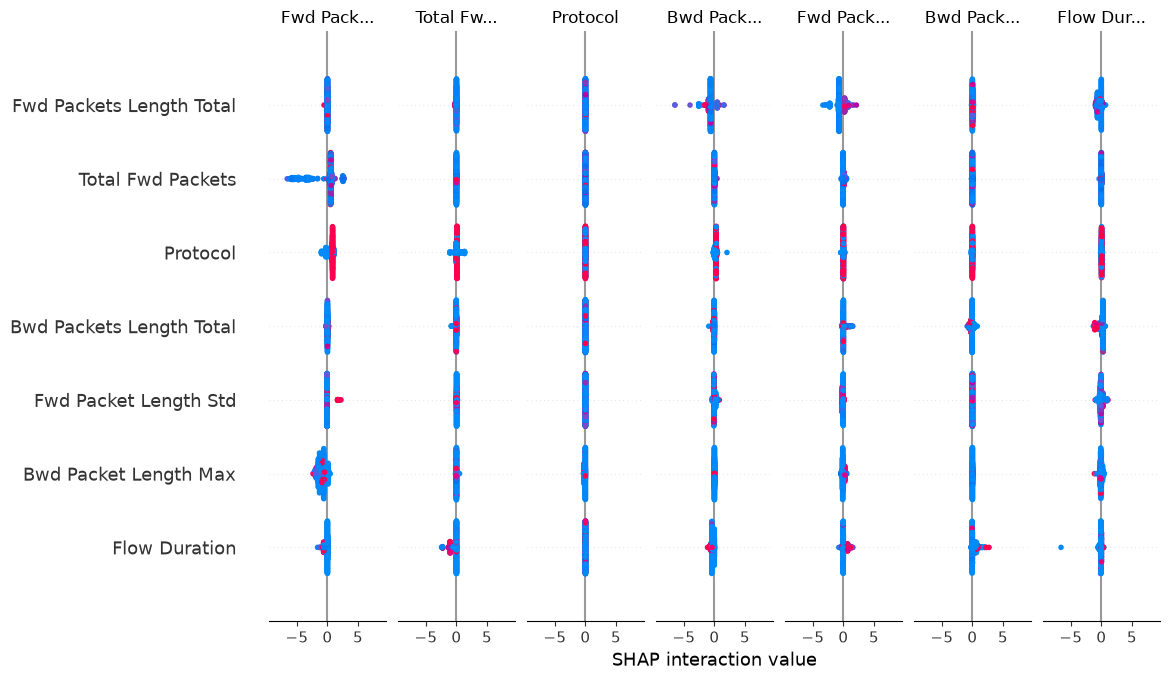

In [81]:
shap.summary_plot(
    shap_values,
    X_test2.iloc[:500]
)

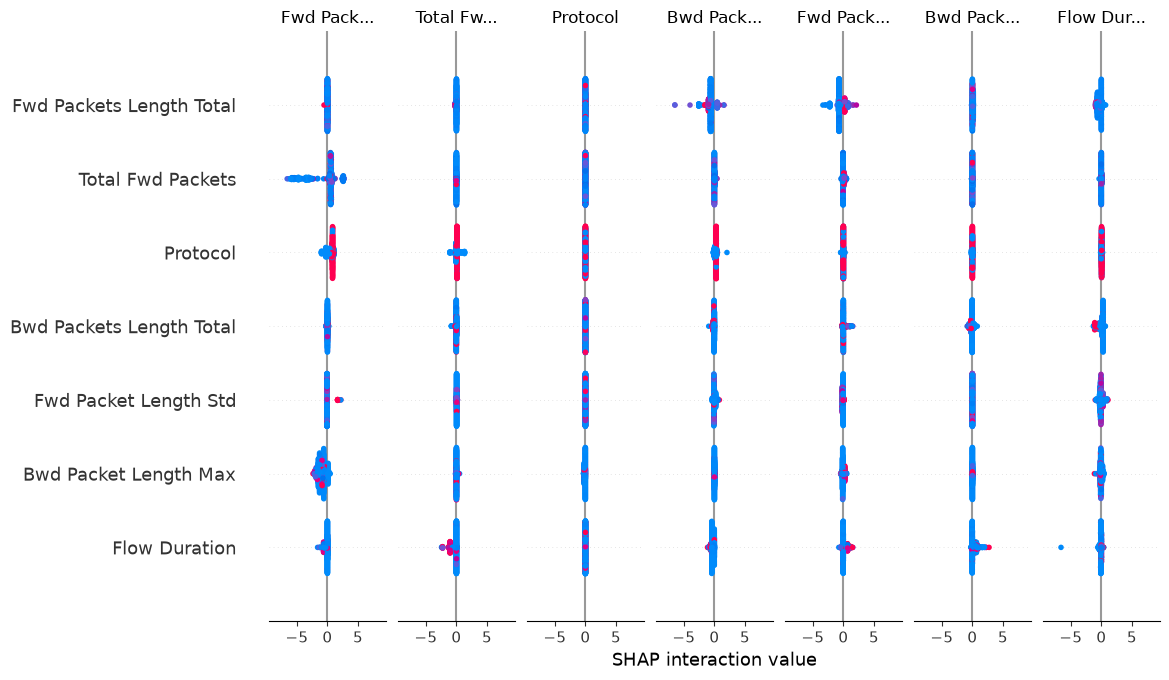

In [82]:
shap.summary_plot(
    shap_values,
    X_test2.iloc[:500]
)

In [84]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(500, 77, 15)


In [85]:
pred_class = y_pred_xgb[0]
print(pred_class)

0


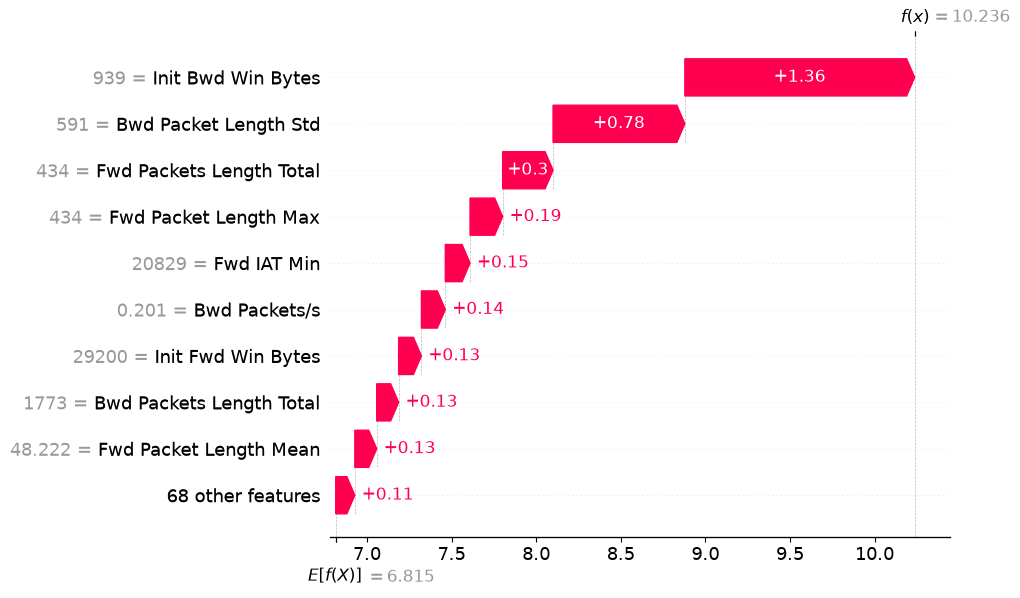

In [86]:
import shap

pred_class = y_pred_xgb[0]

exp = shap.Explanation(
    values=shap_values[0, :, pred_class],
    base_values=explainer.expected_value[pred_class],
    data=X_test2.iloc[0],
    feature_names=X.columns
)

shap.plots.waterfall(exp)

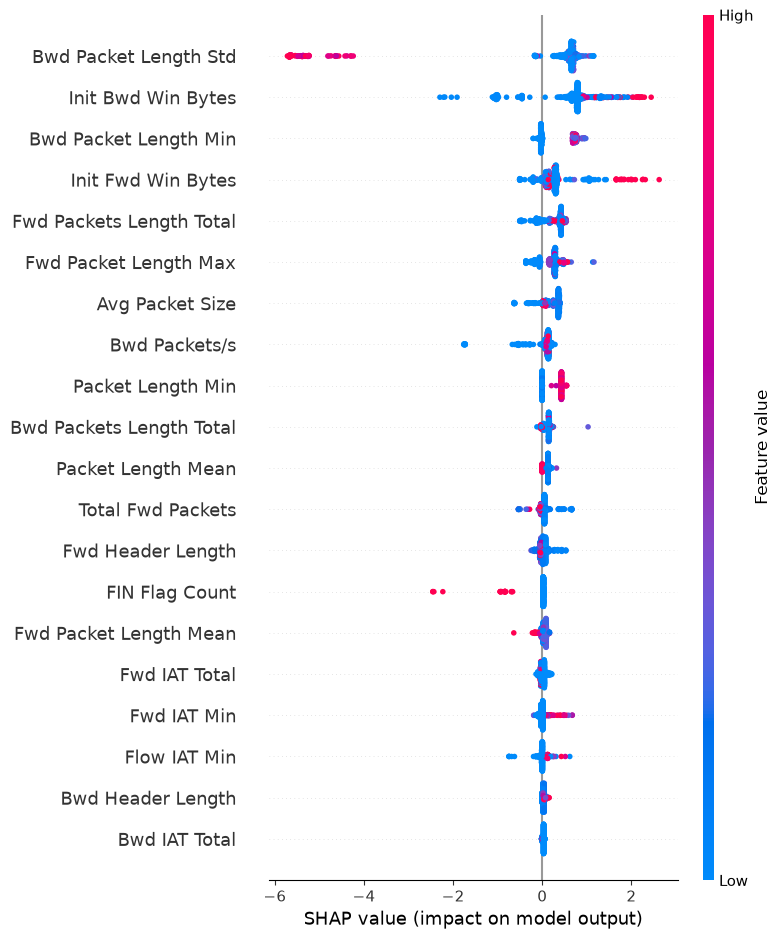

In [87]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_test2.iloc[:500]
)

# 13 Veri Dengesizliğinin Giderilmesi (SMOTE)

### 13.0 SMOTE Uygulaması 

Veri setinde sınıf dengesizliği bulunduğu için SMOTE yöntemi uygulanması planlanmıştır. Ancak CICIDS2017 veri setinin yaklaşık 2.3 milyon örnek içermesi nedeniyle tam veri üzerinde SMOTE işlemi çok yüksek bellek ve işlem süresi gerektirmektedir.

Bu nedenle mevcut çalışmada sınıf ağırlıkları ve güçlü topluluk öğrenme algoritmaları (Random Forest ve XGBoost) tercih edilmiştir. Gelecek çalışmalarda daha güçlü donanım üzerinde SMOTE uygulanarak sonuçların karşılaştırılması planlanmaktadır.